Install required libraries

In [ ]:
!pip install -qU transformers datasets peft bitsandbytes accelerate sacrebleu evaluate groq bert_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 33.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.1/76.1 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.2/122.2 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:

import os
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset, Dataset, concatenate_datasets
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling
)
from peft import (
    prepare_model_for_kbit_training,
    LoraConfig,
    get_peft_model,
    PeftModel,
    PeftConfig, TaskType, AutoPeftModelForCausalLM
)
from tqdm import tqdm
import evaluate
from google.colab import userdata
import requests
import json
import time
from groq import Groq
import re
import sacrebleu
from google.colab import files
import seaborn as sns
from glob import glob

In [ ]:

HF_API_TOKEN = userdata.get('HF_TOKEN')
GROQ_API_TOKEN = userdata.get('GROQ_TOKEN')



os.environ["HF_TOKEN"] = HF_API_TOKEN
os.environ["GROQ_TOKEN"] = GROQ_API_TOKEN

In [ ]:
eval_results_a_filename = "evaluation_results_a.json"
eval_results_b_filename = "evaluation_results_b.json"
eval_results_c_filename = "evaluation_results_c.json"
eval_results_d_filename = "evaluation_results_d.json"

1:

Optional : Load the tatoeba dataset from Huggingface.

In [ ]:
from datasets import load_dataset

# Load Tatoeba dataset
dataset = load_dataset("tatoeba", lang1="de", lang2="fr", trust_remote_code=True)
dataset = dataset["train"].shuffle(seed=42).select(range(1000))  # Select 1,000 pairs

train_test_split = dataset.train_test_split(test_size=0.2)
train_dataset_A = train_test_split["train"]
test_dataset_A = train_test_split["test"]

train_A_df = train_dataset_A.to_pandas()
test_A_df = test_dataset_A.to_pandas()

train_A_df.to_json("train_dataset_A.json", orient="records", lines=True)
test_A_df.to_json("test_dataset_A.json", orient="records", lines=True)

If json is available, load the dataset from json files

In [ ]:
train_A_df = pd.read_json("train_dataset_A.json", lines=True)
test_A_df = pd.read_json("test_dataset_A.json", lines=True)

train_dataset_A = Dataset.from_pandas(train_A_df)
test_dataset_A = Dataset.from_pandas(test_A_df)

Convert dataset to instruction format

In [ ]:
# Define a function to build a prompt from a data example
def format_instruction(german, french):
    return f"""Instruction: Translate the following German sentence into French.\nGerman: {german.strip()}\nFrench: {french.strip()}
"""

# Define a function that converts a dataset row into the corresponding prompt format
def convert_to_instruction_format(data_point):
    return {
        "text": format_instruction(data_point["translation"]["de"], data_point["translation"]["fr"])
        }

# Apply the function to each row in the dataset
def process_dataset(data):
    return data.map(
        convert_to_instruction_format
        ).remove_columns(['translation']) #removing unnecessary columns

train_data_A = process_dataset(
    train_dataset_A
)


print(train_data_A['text'][0])
print(train_data_A['text'][100])

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Instruction: Translate the following German sentence into French.
German: Ich habe etwas sehr Ungewöhnliches gesehen.
French: J'ai vu quelque chose de très inhabituel.

Instruction: Translate the following German sentence into French.
German: Er schlug den Hund mit einem Stock.
French: Il frappa le chien avec un bâton.



2:

Load the base model/model A: - bloomz3b with quantization


Before fine tuning model-b, model-c, model-d, we need to run this cell.

In [ ]:
# Load Base Model (BLOOMZ-3b) with 4-bit Quantization
model_name = "bigscience/bloomz-3b"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load model with quantization
print("Loading BLOOMZ-3b with 4-bit quantization...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

tokenizer_config.json:   0%|          | 0.00/199 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Loading BLOOMZ-3b with 4-bit quantization...


config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/6.01G [00:00<?, ?B/s]

Evaluate translations with SacreBLEU and BERT scores

In [ ]:

def evaluate_translations(model, tokenizer, test_data, device=None, beam_size=5,
                          print_examples=3, temperature=0.3):
    """
    Translation evaluation using both SacreBLEU and BERTScore metrics.
    """
    # Import BERTScore evaluator
    import evaluate
    bertscore = evaluate.load("bertscore")

    # Determine device
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # Ensure model is on the correct device
    model = model.to(device)

    model.eval()

    # Generation config
    gen_kwargs = {
        "max_new_tokens": 128,
        "num_beams": beam_size,
        "temperature": temperature,
        "no_repeat_ngram_size": 3,
        "do_sample": temperature > 0,
        "early_stopping": True
    }

    # Results storage
    results = []
    all_references = []
    all_generated = []
    bleu_scores = []
    bert_precision_scores = []
    bert_recall_scores = []
    bert_f1_scores = []

    # Create custom tqdm progress bar with metrics
    progress_bar = tqdm(test_data, desc="Evaluating translations")

    # Process each example
    for example in progress_bar:
        # Get data
        source = example['translation']['de']
        reference = example['translation']['fr']

        # Create clear, simple prompt
        prompt = f"Instruction: Translate the following German sentence into French.\nGerman: {source}\nFrench:"

        # Tokenize and generate
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            output_ids = model.generate(**inputs, **gen_kwargs)

        # Decode output
        full_output = tokenizer.decode(output_ids[0], skip_special_tokens=True)

        # Extract translation (everything after "French:")
        generated = full_output.split("French:")[-1].strip() if "French:" in full_output else full_output


        reference = reference.strip().lower()
        generated = generated.strip().lower()

        # Calculate SacreBLEU score
        bleu_score = sacrebleu.sentence_bleu(generated, [reference]).score

        # Calculate BERTScore (using French as language)
        bert_results = bertscore.compute(
            predictions=[generated],
            references=[reference],
            lang="fr",
            model_type="distilbert-base-multilingual-cased"  # More efficient model for multilingual use
        )

        # Store metrics
        bleu_scores.append(bleu_score)
        bert_precision_scores.append(bert_results['precision'][0])
        bert_recall_scores.append(bert_results['recall'][0])
        bert_f1_scores.append(bert_results['f1'][0])

        all_references.append(reference)
        all_generated.append(generated)

        # Update tqdm progress bar with running averages
        progress_bar.set_postfix({
            'BLEU': f"{np.mean(bleu_scores):.2f}",
            'BERTScore': f"{np.mean(bert_f1_scores):.2f}"
        })

        results.append({
            'id': example.get('id', ''),
            'source': source,
            'reference': reference,
            'generated': generated,
            'sacrebleu': bleu_score,
            'bertscore_precision': bert_results['precision'][0],
            'bertscore_recall': bert_results['recall'][0],
            'bertscore_f1': bert_results['f1'][0]
        })

    # Calculate average scores
    avg_bleu = np.mean(bleu_scores)
    avg_bert_precision = np.mean(bert_precision_scores)
    avg_bert_recall = np.mean(bert_recall_scores)
    avg_bert_f1 = np.mean(bert_f1_scores)

    # Print results
    print(f"\nEvaluation Results:")
    print(f"Average sentence SacreBLEU score: {avg_bleu:.4f}")
    print(f"Average BERTScore - Precision: {avg_bert_precision:.4f}")
    print(f"Average BERTScore - Recall: {avg_bert_recall:.4f}")
    print(f"Average BERTScore - F1: {avg_bert_f1:.4f}")

    # Print examples
    if print_examples > 0:
        print(f"\nExample translations ({min(print_examples, len(results))} of {len(results)}):")
        for i, example in enumerate(results[:print_examples]):
            print("-" * 60)
            print(f"Example {i+1}:")
            print(f"Source (DE): {example['source']}")
            print(f"Reference (FR): {example['reference']}")
            print(f"Generated (FR): {example['generated']}")
            print(f"SacreBLEU: {example['sacrebleu']:.4f}")
            print(f"BERTScore - F1: {example['bertscore_f1']:.4f}")
        print("-" * 60)

    # Return both BLEU and BERTScore metrics
    return {
        'bleu': avg_bleu,
        'bertscore_precision': avg_bert_precision,
        'bertscore_recall': avg_bert_recall,
        'bertscore_f1': avg_bert_f1,
        'detailed_results': results
    }

3:

evaluate score for model A

In [ ]:
results_A = evaluate_translations(
    model,
    tokenizer,
    test_dataset_A,
    device="cuda",
    beam_size=5,
    temperature=0.5,
    print_examples=5,
)

# Save Model A results
model_A_results = {
    "model_name": "Model A (Baseline)",
    "bleu": round(results_A["bleu"],4),
    "bertscore_f1": round(results_A["bertscore_f1"],4)
}

with open(eval_results_a_filename, 'w') as f:
    json.dump(model_A_results, f, indent=2)

Using device: cuda


Evaluating translations:   0%|          | 0/200 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Evaluating translations: 100%|██████████| 200/200 [03:32<00:00,  1.06s/it, BLEU=25.63, BERTScore=0.92]


Evaluation Results:
Average sentence SacreBLEU score: 25.6303
Average BERTScore - Precision: 0.9157
Average BERTScore - Recall: 0.9151
Average BERTScore - F1: 0.9152

Example translations (5 of 200):
------------------------------------------------------------
Example 1:
Source (DE): Sie ging hinaus, ohne auf Wiedersehen zu sagen.
Reference (FR): elle est sortie sans dire au revoir.
Generated (FR): vous êtes venue chez nous, sans dire au revoir.
SacreBLEU: 35.0844
BERTScore - F1: 0.9226
------------------------------------------------------------
Example 2:
Source (DE): Ich weiß, dass Sie sich hinter der Gardine verstecken.
Reference (FR): je sais que vous vous cachez derrière le rideau.
Generated (FR): je sais que vous vous trouvez à l'intérieur de la garderie.
SacreBLEU: 33.1808
BERTScore - F1: 0.9314
------------------------------------------------------------
Example 3:
Source (DE): Du bist den Menschen in deiner Umgebung gegenüber zu gleichgültig.
Reference (FR): tu es trop indif

4:

Prepare model a/base model for finetuning with LoRA
Config:
r=16,
lora_alpha=64,
target_modules = query_key_value
dropout = 0.1
task_type = CAUSAL_LM
modules_to_save = lm_head (List of modules apart from adapter layers to be set as trainable and saved in the final checkpoint.) (important for generating high quality outputs)


run this before fine tuning model-b, model-c, model-d

In [ ]:
# Prepare the model for LoRA, which includes float conversions to help stabilize training
model = prepare_model_for_kbit_training(model)

# Set up LoRA configuration
lora_config = LoraConfig(
    r=16,                                                       # The rank (dimensions) of the LoRA matrices A and B
    lora_alpha=64,                                              # Scales the product of matrices AB [W_new = W_old + (A * B) * α]
    target_modules=["query_key_value"],    # Apply LoRA to the attention matrices
    lora_dropout=0.1,                                           # Dropout rate to reduce overfitting
    bias="none",                                                # Do not train the bias parameter
    task_type="CAUSAL_LM", # Task type for autoregressive text generation
    modules_to_save=['lm_head'],
)

# Get the model with unfrozen LoRA layers applied
model = get_peft_model(model, lora_config)

Tokenize the training dataset for model-b

In [ ]:
#Ensure base model, tokenizer is loaded
def preprocess_function(examples):
  tokenized = tokenizer(
      examples["text"],
      padding="max_length",
      add_special_tokens=True,
      max_length=128,
      truncation=True,
  )
  tokenized["labels"] = tokenized["input_ids"].copy()
  return tokenized

tokenized_train_data_A = train_data_A.map(preprocess_function, batched=True, remove_columns=["text"])

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Prepare training with lora parameters for model-b

In [ ]:
# Set up the training hyperparameters
training_arguments = TrainingArguments(
    fp16=True,                           # Use 16-bit precision for training computations (optimizer states, gradients)

    # Batch-related parameters
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,# Batch size per device during training

    # Optimizer-related parameters
    optim="paged_adamw_8bit",           # Use the paged AdamW optimizer, optimized for 32-bit GPUs
    learning_rate=2e-5,                  # Set the learning rate for training

    # Epochs and saving configuration
    num_train_epochs=2,                  # Number of training epochs (more epochs generally lead to better results)
    save_strategy="epoch",               # Save the model after each epoch
    output_dir="./model-b",      # Directory to save the fine-tuned model

    # Logging-related parameters
    report_to="none",                    # Disable reporting to external tools
    logging_dir="./logs",                # Directory to save the training logs
    logging_steps=20,                    # Number of steps between each log entry
    seed=42,                             # Set a random seed for reproducibility
    gradient_checkpointing=True,
)


# Disable attention cache during training; it should be enabled during inference
model.config.use_cache = "False"

model.print_trainable_parameters()

trainable params: 647,168,000 || all params: 3,649,725,440 || trainable%: 17.7320


In [ ]:
# Initialize the trainer
trainer = Trainer(
    # Assign the model and tokenizer
    model=model,
    tokenizer=tokenizer,

    # Provide the training dataset
    train_dataset=tokenized_train_data_A,

    # Set the training hyperparameters
    args=training_arguments,
)

<ipython-input-24-0c11265b87b7>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Train the model-b

In [ ]:
trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
20,2.085800
40,0.744400
60,0.478400
80,0.553500
100,0.467800
120,0.404000
140,0.382100
160,0.418600
180,0.441800
200,0.422100


TrainOutput(global_step=200, training_loss=0.6398577523231507, metrics={'train_runtime': 1102.5536, 'train_samples_per_second': 1.451, 'train_steps_per_second': 0.181, 'total_flos': 3695582380032000.0, 'train_loss': 0.6398577523231507, 'epoch': 2.0})

Save model b

In [ ]:
# Define the save path for the fine-tuned model on Colab
peft_model_path = './model-b/checkpoint-200'

# Save the trained model
trainer.model.save_pretrained(peft_model_path)

# Save the tokenizer
tokenizer.save_pretrained(peft_model_path)

# List the saved files
!ls -lh {peft_model_path}

total 3.7G
-rw-r--r-- 1 root root  726 Mar 13 12:39 adapter_config.json
-rw-r--r-- 1 root root 2.5G Mar 13 12:39 adapter_model.safetensors
-rw-r--r-- 1 root root 1.3G Mar 13 12:38 optimizer.pt
-rw-r--r-- 1 root root 5.0K Mar 13 12:38 README.md
-rw-r--r-- 1 root root  14K Mar 13 12:38 rng_state.pth
-rw-r--r-- 1 root root  988 Mar 13 12:38 scaler.pt
-rw-r--r-- 1 root root 1.1K Mar 13 12:38 scheduler.pt
-rw-r--r-- 1 root root  437 Mar 13 12:39 special_tokens_map.json
-rw-r--r-- 1 root root 1.1K Mar 13 12:39 tokenizer_config.json
-rw-r--r-- 1 root root  21M Mar 13 12:39 tokenizer.json
-rw-r--r-- 1 root root 2.3K Mar 13 12:38 trainer_state.json
-rw-r--r-- 1 root root 5.2K Mar 13 12:38 training_args.bin


Load model b from checkpoint for evaluation

In [ ]:

peft_model_path = './model-b/checkpoint-200'

# Load Base Model (BLOOMZ-3b) with 4-bit Quantization
model_name = "bigscience/bloomz-3b"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(peft_model_path)

# Set the padding token to be the same as the end-of-sequence token
tokenizer.pad_token = tokenizer.eos_token

# Specify that padding should be added to the right side of the sequences
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

tuned_model = PeftModel.from_pretrained(base_model, peft_model_path)



# Enable attention cache during inference
tuned_model.config.use_cache = True

tuned_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): BloomForCausalLM(
      (transformer): BloomModel(
        (word_embeddings): Embedding(250880, 2560)
        (word_embeddings_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (h): ModuleList(
          (0-29): 30 x BloomBlock(
            (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
            (self_attention): BloomAttention(
              (query_key_value): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2560, out_features=7680, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2560, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=7680, bias=False)
                )
              

5:

Evaluate model b

In [ ]:
results_B = evaluate_translations(
    tuned_model,
    tokenizer,
    test_dataset_A,
    device="cuda",
    beam_size=5,
    temperature=0.5,
    print_examples=5,
)

# Save Model A results
model_B_results = {
    "model_name": "Model B",
    "bleu": round(results_B["bleu"],4),
    "bertscore_f1": round(results_B["bertscore_f1"],4)
}

with open(eval_results_b_filename, 'w') as f:
    json.dump(model_B_results, f, indent=2)

Using device: cuda


Evaluating translations: 100%|██████████| 200/200 [03:32<00:00,  1.06s/it, BLEU=39.91, BERTScore=0.94]


Evaluation Results:
Average sentence SacreBLEU score: 39.9132
Average BERTScore - Precision: 0.9386
Average BERTScore - Recall: 0.9352
Average BERTScore - F1: 0.9368

Example translations (5 of 200):
------------------------------------------------------------
Example 1:
Source (DE): Sie ging hinaus, ohne auf Wiedersehen zu sagen.
Reference (FR): elle est sortie sans dire au revoir.
Generated (FR): elle est venue ici sans dire au revoir.
SacreBLEU: 51.3345
BERTScore - F1: 0.9825
------------------------------------------------------------
Example 2:
Source (DE): Ich weiß, dass Sie sich hinter der Gardine verstecken.
Reference (FR): je sais que vous vous cachez derrière le rideau.
Generated (FR): je sais que vous vous cachez derrière le rideau.
SacreBLEU: 100.0000
BERTScore - F1: 1.0000
------------------------------------------------------------
Example 3:
Source (DE): Du bist den Menschen in deiner Umgebung gegenüber zu gleichgültig.
Reference (FR): tu es trop indifférent aux gens de

6:

Synthetic data generation(2x the length of training data) with GROQ API. Model used - llama3-70b

Prompt - "I need you to create {num_examples} high-quality, diverse German-French translation pairs.

Guidelines:
1. Create natural, fluent sentences a native speaker would use
2. Include a variety of topics: everyday conversations, business, travel, technology, culture, etc.
3. Ensure grammatical correctness in both languages

Format each translation pair exactly like this:
German: [German sentence]
French: [French translation]

Please generate {num_examples} new and diverse German-French translation pairs following the format above. Make sure they cover different topics and sentence structures."

In [ ]:
def generate_translations_with_groq(prompt, api_key, model_name="llama3-70b-8192"):
    """Generate text using Groq API"""
    # Initialize Groq client
    client = Groq(api_key=api_key)

    try:
        # Call the Groq API
        completion = client.chat.completions.create(
            model=model_name,
            messages=[
                {"role": "system", "content": "You are an expert German-French translator."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.7,
            max_tokens=2048,
            top_p=0.9,
            stream=False
        )

        # Return the generated content
        return completion.choices[0].message.content

    except Exception as e:
        print(f"Error calling Groq API: {e}")
        time.sleep(10)  # Wait a bit before retrying
        return None

In [ ]:
def create_groq_prompt(num_examples=10):
    """Create a prompt for generating German-French translation pairs"""
    # Start with clear instructions
    prompt = f"""I need you to create {num_examples} high-quality, diverse German-French translation pairs.

Guidelines:
1. Create natural, fluent sentences a native speaker would use
2. Include a variety of topics: everyday conversations, business, travel, technology, culture, etc.
3. Ensure grammatical correctness in both languages

Format each translation pair exactly like this:
German: [German sentence]
French: [French translation]

"""

    # Add final instruction
    prompt += f"Please generate {num_examples} new and diverse German-French translation pairs following the format above. Make sure they cover different topics and sentence structures."

    return prompt

In [ ]:
def parse_generated_translations(text):
    """Parse generated text to extract German-French translation pairs."""
    pairs = []

    # Use regex to find patterns like "German: text" and "French: text"
    german_pattern = r"(?:^|\n)(?:\d+\.?\s*)?(?:\*\*\d+\.\s*[^*]*\*\*\s*)?German:\s*(.*?)(?=\n|$)"
    french_pattern = r"(?:^|\n)(?:\d+\.?\s*)?French:\s*(.*?)(?=\n|$)"

    # Find all German lines
    german_matches = re.finditer(german_pattern, text, re.MULTILINE)

    for german_match in german_matches:
        german_text = german_match.group(1).strip()

        # Find the next French line after this German line
        start_pos = german_match.end()
        french_match = re.search(french_pattern, text[start_pos:], re.MULTILINE)

        if french_match:
            french_text = french_match.group(1).strip()

            # Add only if both texts are valid
            if german_text and french_text:
                # Format pair in Tatoeba structure
                pairs.append({
                    "id": None,  # We'll generate IDs later
                    "translation": {
                        "de": german_text,
                        "fr": french_text
                    }
                })

    return pairs

In [ ]:
def generate_synthetic_dataset(api_key, model_name="llama3-70b-8192", batch_size=10, total_examples=1600):
    """Generate synthetic German-French translation pairs in Tatoeba format"""

    # Track already generated pairs using tuples of (de, fr)
    synthetic_pair_set = set()

    # Initialize empty list for synthetic data
    synthetic_data = []

    # Start ID for synthetic data (choose a range that won't conflict with real Tatoeba IDs)
    # Tatoeba IDs are typically integers, so we'll use a prefix or high range
    start_id = 1000000  # Start at 1 million to avoid conflicts

    # Track batches
    batch_count = 0

    # Continue generating until we reach exactly total_examples unique pairs
    pbar = tqdm(total=total_examples, desc="Generating synthetic data")

    while len(synthetic_data) < total_examples:
        batch_count += 1

        # Create prompt for this batch
        prompt = create_groq_prompt(batch_size)

        # Generate text
        generated_text = generate_translations_with_groq(prompt, api_key, model_name)

        if generated_text:
            # Parse the generated text to extract translation pairs
            pairs = parse_generated_translations(generated_text)

            # Track new unique pairs added in this batch
            new_unique_count = 0

            # Check and add only unique pairs
            if pairs:
                for pair in pairs:
                    # Extract texts for comparison
                    german_text = pair["translation"]["de"]
                    french_text = pair["translation"]["fr"]
                    pair_tuple = (german_text, french_text)

                    # Only add if not a duplicate
                    if pair_tuple not in synthetic_pair_set:
                        # Assign a unique ID
                        pair["id"] = start_id + len(synthetic_data)

                        # Add to dataset
                        synthetic_data.append(pair)
                        synthetic_pair_set.add(pair_tuple)
                        new_unique_count += 1
                        pbar.update(1)

                        # Stop if we've reached our target
                        if len(synthetic_data) >= total_examples:
                            break

            print(f"Batch {batch_count}: Added {new_unique_count} unique pairs (filtered {len(pairs) - new_unique_count} duplicates)")
            print(f"Progress: {len(synthetic_data)}/{total_examples} unique pairs")

            # Print example pairs for the first 2 batches
            if batch_count <= 2:
                print("\nExample pairs from batch:")
                for i in range(min(3, len(pairs))):
                    print(f"Pair {i+1}:")
                    print(f"ID: {pairs[i]['id']}")
                    print(f"German: {pairs[i]['translation']['de']}")
                    print(f"French: {pairs[i]['translation']['fr']}")
                    is_duplicate = (pairs[i]['translation']['de'], pairs[i]['translation']['fr']) in synthetic_pair_set and \
                                 len([p for p in synthetic_data if
                                      p['translation']['de'] == pairs[i]['translation']['de'] and
                                      p['translation']['fr'] == pairs[i]['translation']['fr']]) > 1
                    print(f"Is duplicate: {is_duplicate}")
                    print("---")
                print()

            # Add some delay to respect API rate limits
            time.sleep(1)

    pbar.close()

    # Create DataFrame from synthetic data
    synthetic_df = pd.DataFrame(synthetic_data)

    print(f"Successfully generated exactly {len(synthetic_df)} unique synthetic translation pairs")
    print(f"Filtered out {len(synthetic_pair_set) - len(synthetic_df)} duplicates during generation")

    return synthetic_df

In [ ]:
def generate_and_prepare_synthetic_data(api_key, output_path=None, model_name="llama3-70b-8192", target_size=1600):
    """Generate synthetic data and prepare it for training"""

    # Generate synthetic data
    synthetic_df = generate_synthetic_dataset(
        api_key,
        model_name=model_name,
        batch_size=10,
        total_examples=target_size
    )

    # Save the data in JSONL format to match Tatoeba
    synthetic_df.to_json(output_path, orient="records", lines=True)
    print(f"Synthetic data saved to {output_path}")

    # Convert to HuggingFace Dataset
    synthetic_dataset = Dataset.from_pandas(synthetic_df)


    return synthetic_df, synthetic_dataset

Load synthetic data from json files if available

In [ ]:
target_size = 2*len(train_A_df)


#If json files are not available, uncomment the below code
#synthetic_df, synthetic_dataset = generate_and_prepare_synthetic_data(
#        GROQ_TOKEN,
#        output_path="dataset_B.json",
#        model_name="llama3-70b-8192",
#        target_size=target_size)



dataset_B_df = pd.read_json('dataset_B.json', lines=True)
# Convert to HuggingFace Dataset
dataset_B = Dataset.from_pandas(dataset_B_df)

# Print column names to verify
print(f"Synthetic dataset columns: {dataset_B.column_names}")

def format_instruction(german, french):
    return f"""Instruction: Translate the following German sentence into French.\nGerman: {german.strip()}\nFrench: {french.strip()}
"""

# Define a function that converts a dataset row into the corresponding prompt format
def convert_synthetic_to_instruction_format(data_point):
    return {
        "text": format_instruction(data_point["translation"]["de"], data_point["translation"]["fr"])
        }

# Apply the function to each row in the dataset
def process_synthetic_dataset(data):
    return data.map(
        convert_synthetic_to_instruction_format
        ).remove_columns(data.column_names) #removing unnecessary columns

data_B = process_synthetic_dataset(
    dataset_B
)


print(data_B['text'][0])
print(data_B['text'][100])

Synthetic dataset columns: ['id', 'translation']


Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Instruction: Translate the following German sentence into French.
German: Ich brauche eine neue Tasche für meine Reise nach Paris.
French: J'ai besoin d'un nouveau sac pour mon voyage à Paris.

Instruction: Translate the following German sentence into French.
German: Die neue App ermöglicht es uns, unsere Reisepläne leicht zu organisieren und zu teilen.
French: La nouvelle application nous permet d'organiser et de partager facilement nos plans de voyage.



7:

Tokenize dataset for training on model-c

In [ ]:
#Ensure base model, tokenizer is loaded
def preprocess_function(examples):
  tokenized = tokenizer(
      examples["text"],
      padding="max_length",
      add_special_tokens=True,
      max_length=128,
      truncation=True,
  )
  tokenized["labels"] = tokenized["input_ids"].copy()
  return tokenized

tokenized_dataset_B = data_B.map(preprocess_function, batched=True, remove_columns=["text"])

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Prepare training with lora parameters for model c

In [ ]:
# Set up the training hyperparameters
training_arguments = TrainingArguments(
    fp16=True,                           # Use 16-bit precision for training computations (optimizer states, gradients)

    # Batch-related parameters
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,# Batch size per device during training

    # Optimizer-related parameters
    optim="paged_adamw_8bit",           # Use the paged AdamW optimizer, optimized for 32-bit GPUs
    learning_rate=2e-5,                  # Set the learning rate for training

    # Epochs and saving configuration
    num_train_epochs=2,                  # Number of training epochs (more epochs generally lead to better results)
    save_strategy="epoch",               # Save the model after each epoch
    output_dir="./model-c",      # Directory to save the fine-tuned model

    # Logging-related parameters
    report_to="none",                    # Disable reporting to external tools
    logging_dir="./logs",                # Directory to save the training logs
    logging_steps=20,                    # Number of steps between each log entry
    seed=42,                             # Set a random seed for reproducibility
    gradient_checkpointing=True,
)


# Disable attention cache during training; it should be enabled during inference
model.config.use_cache = "False"

model.print_trainable_parameters()

trainable params: 647,168,000 || all params: 3,649,725,440 || trainable%: 17.7320


In [ ]:
# Initialize the trainer
trainer = Trainer(
    # Assign the model and tokenizer
    model=model,
    tokenizer=tokenizer,

    # Provide the training and validation datasets
    train_dataset=tokenized_dataset_B,

    # Set the training hyperparameters
    args=training_arguments,
)

<ipython-input-16-13a51a4514cc>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
20,2.003400
40,0.742800
60,0.525600
80,0.470400
100,0.440200
120,0.422800
140,0.421400
160,0.366300
180,0.425000
200,0.388000


TrainOutput(global_step=400, training_loss=0.4664907908439636, metrics={'train_runtime': 1792.6873, 'train_samples_per_second': 1.785, 'train_steps_per_second': 0.223, 'total_flos': 7391164760064000.0, 'train_loss': 0.4664907908439636, 'epoch': 2.0})

Save model c

In [ ]:
# Define the save path for the fine-tuned model on Colab
peft_model_path = './model-c/checkpoint-400'

# Save the trained model
trainer.model.save_pretrained(peft_model_path)

# Save the tokenizer
tokenizer.save_pretrained(peft_model_path)

# List the saved files
!ls -lh {peft_model_path}

total 3.7G
-rw-r--r-- 1 root root  726 Mar 12 11:20 adapter_config.json
-rw-r--r-- 1 root root 2.5G Mar 12 11:20 adapter_model.safetensors
-rw-r--r-- 1 root root 1.3G Mar 12 11:17 optimizer.pt
-rw-r--r-- 1 root root 5.0K Mar 12 11:18 README.md
-rw-r--r-- 1 root root  14K Mar 12 11:17 rng_state.pth
-rw-r--r-- 1 root root  988 Mar 12 11:17 scaler.pt
-rw-r--r-- 1 root root 1.1K Mar 12 11:17 scheduler.pt
-rw-r--r-- 1 root root  437 Mar 12 11:20 special_tokens_map.json
-rw-r--r-- 1 root root 1.1K Mar 12 11:20 tokenizer_config.json
-rw-r--r-- 1 root root  21M Mar 12 11:20 tokenizer.json
-rw-r--r-- 1 root root 3.7K Mar 12 11:17 trainer_state.json
-rw-r--r-- 1 root root 5.2K Mar 12 11:17 training_args.bin


Load model c for evaluation

In [ ]:

peft_model_path = './model-c/checkpoint-400'

# 4. Load Base Model (BLOOMZ-3b) with 4-bit Quantization
model_name = "bigscience/bloomz-3b"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(peft_model_path)

# Set the padding token to be the same as the end-of-sequence token
tokenizer.pad_token = tokenizer.eos_token

# Specify that padding should be added to the right side of the sequences
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

tuned_model = PeftModel.from_pretrained(base_model, peft_model_path)



# Enable attention cache during inference
tuned_model.config.use_cache = True

tuned_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): BloomForCausalLM(
      (transformer): BloomModel(
        (word_embeddings): Embedding(250880, 2560)
        (word_embeddings_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (h): ModuleList(
          (0-29): 30 x BloomBlock(
            (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
            (self_attention): BloomAttention(
              (query_key_value): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2560, out_features=7680, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2560, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=7680, bias=False)
                )
              

8:

Evaluate model c

In [ ]:
results_C = evaluate_translations(
    tuned_model,
    tokenizer,
    test_dataset_A,
    device="cuda",
    beam_size=5,
    temperature=0.5,
    print_examples=5,
)

# Save Model C results
model_C_results = {
    "model_name": "Model C",
    "bleu": round(results_C["bleu"],4),
    "bertscore_f1": round(results_C["bertscore_f1"],4)
}

with open(eval_results_c_filename, 'w') as f:
    json.dump(model_C_results, f, indent=2)

Using device: cuda


Evaluating translations: 100%|██████████| 200/200 [03:59<00:00,  1.20s/it, BLEU=25.60, BERTScore=0.91]


Evaluation Results:
Average sentence SacreBLEU score: 25.5982
Average BERTScore - Precision: 0.9137
Average BERTScore - Recall: 0.9159
Average BERTScore - F1: 0.9146

Example translations (5 of 200):
------------------------------------------------------------
Example 1:
Source (DE): Sie ging hinaus, ohne auf Wiedersehen zu sagen.
Reference (FR): elle est sortie sans dire au revoir.
Generated (FR): vous êtes venus sans me dire au revoir.
SacreBLEU: 31.5598
BERTScore - F1: 0.9135
------------------------------------------------------------
Example 2:
Source (DE): Ich weiß, dass Sie sich hinter der Gardine verstecken.
Reference (FR): je sais que vous vous cachez derrière le rideau.
Generated (FR): je sais que vous vous asseyez près de la fontaine.
SacreBLEU: 36.7206
BERTScore - F1: 0.9363
------------------------------------------------------------
Example 3:
Source (DE): Du bist den Menschen in deiner Umgebung gegenüber zu gleichgültig.
Reference (FR): tu es trop indifférent aux gens d

9:

Combine and shuffle synthetic data and train data to form combined data C

In [ ]:
# Combine both datasets, if json file is not available,
# uncomment the following code after loading the dataset_B and dataset_A(train)
# and procesing them

#combined_dataset = concatenate_datasets([train_dataset_A, dataset_B])
# Shuffle the combined dataset with a fixed seed for reproducibility
#seed = 42
#dataset_C = combined_dataset.shuffle(seed=seed)
#dataset_C_df = dataset_C.to_pandas()
#dataset_C_df.to_json("dataset_C.json", orient="records", lines=True)


# If json is available, read from json file
dataset_C_df = pd.read_json('dataset_C.json', lines=True)

# Convert to HuggingFace Dataset
dataset_C = Dataset.from_pandas(dataset_C_df)
print(dataset_C.column_names)

def format_instruction(german, french):
    return f"""Instruction: Translate the following German sentence into French.\nGerman: {german.strip()}\nFrench: {french.strip()}
"""

# Define a function that converts a dataset row into the corresponding prompt format
def convert_combined_to_instruction_format(data_point):
    return {
        "text": format_instruction(data_point["translation"]["de"], data_point["translation"]["fr"])
        }

# Apply the function to each row in the dataset
def process_combined_dataset(data):
    return data.map(
        convert_combined_to_instruction_format
        ).remove_columns(data.column_names) #removing unnecessary columns

data_C = process_combined_dataset(
    dataset_C
)


print(data_C['text'][0])
print(data_C['text'][100])


#Ensure base model, tokenizer is loaded
def preprocess_function(examples):
  tokenized = tokenizer(
      examples["text"],
      padding="max_length",
      add_special_tokens=True,
      max_length=128,
      truncation=True,
  )
  tokenized["labels"] = tokenized["input_ids"].copy()
  return tokenized

tokenized_data_C = data_C.map(preprocess_function, batched=True, remove_columns=["text"])

['id', 'translation']


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Instruction: Translate the following German sentence into French.
German: Die Firma wird nächsten Monat nach Paris expandieren.
French: L'entreprise va s'étendre à Paris le mois prochain.

Instruction: Translate the following German sentence into French.
German: Würdest du mir diesen Brief frankieren?
French: Est-ce que tu timbrerais cette lettre pour moi ?



Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

10:

Prepare training arguments with lora parameters for model d

In [ ]:
# Set up the training hyperparameters
training_arguments = TrainingArguments(
    fp16=True,                           # Use 16-bit precision for training computations (optimizer states, gradients)

    # Batch-related parameters
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,# Batch size per device during training

    # Optimizer-related parameters
    optim="paged_adamw_8bit",           # Use the paged AdamW optimizer, optimized for 32-bit GPUs
    learning_rate=2e-5,                  # Set the learning rate for training

    # Epochs and saving configuration
    num_train_epochs=2,                  # Number of training epochs (more epochs generally lead to better results)
    save_strategy="epoch",               # Save the model after each epoch
    output_dir="./model-d",      # Directory to save the fine-tuned model

    # Logging-related parameters
    report_to="none",                    # Disable reporting to external tools
    logging_dir="./logs",                # Directory to save the training logs
    logging_steps=20,                    # Number of steps between each log entry
    seed=42,                             # Set a random seed for reproducibility
    gradient_checkpointing=True,
)


# Disable attention cache during training; it should be enabled during inference
model.config.use_cache = "False"

model.print_trainable_parameters()

trainable params: 647,168,000 || all params: 3,649,725,440 || trainable%: 17.7320


In [ ]:
# Initialize the trainer
trainer = Trainer(
    # Assign the model and tokenizer
    model=model,
    tokenizer=tokenizer,

    # Provide the training and validation datasets
    train_dataset=tokenized_data_C,

    # Set the training hyperparameters
    args=training_arguments,
)

<ipython-input-14-f8fe6c4d632a>:2: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForCausalLM`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


In [ ]:
trainer.train()

`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss
20,2.065900
40,0.755100
60,0.487800
80,0.523300
100,0.505100
120,0.492200
140,0.469800
160,0.475500
180,0.484100
200,0.443300


TrainOutput(global_step=600, training_loss=0.47037070671717324, metrics={'train_runtime': 2868.2336, 'train_samples_per_second': 1.674, 'train_steps_per_second': 0.209, 'total_flos': 1.1086747140096e+16, 'train_loss': 0.47037070671717324, 'epoch': 2.0})

Save model d checkpoint

In [ ]:
# Define the save path for the fine-tuned model on Colab
peft_model_path = './model-d/checkpoint-600'

# Save the trained model
trainer.model.save_pretrained(peft_model_path)

# Save the tokenizer
tokenizer.save_pretrained(peft_model_path)

# List the saved files
!ls -lh {peft_model_path}

total 3.7G
-rw-r--r-- 1 root root  726 Mar 13 21:28 adapter_config.json
-rw-r--r-- 1 root root 2.5G Mar 13 21:28 adapter_model.safetensors
-rw-r--r-- 1 root root 1.3G Mar 13 21:25 optimizer.pt
-rw-r--r-- 1 root root 5.0K Mar 13 21:27 README.md
-rw-r--r-- 1 root root  14K Mar 13 21:25 rng_state.pth
-rw-r--r-- 1 root root  988 Mar 13 21:25 scaler.pt
-rw-r--r-- 1 root root 1.1K Mar 13 21:25 scheduler.pt
-rw-r--r-- 1 root root  437 Mar 13 21:28 special_tokens_map.json
-rw-r--r-- 1 root root 1.1K Mar 13 21:28 tokenizer_config.json
-rw-r--r-- 1 root root  21M Mar 13 21:28 tokenizer.json
-rw-r--r-- 1 root root 5.6K Mar 13 21:25 trainer_state.json
-rw-r--r-- 1 root root 5.2K Mar 13 21:25 training_args.bin


Load model d from checkpoint for evaluation

In [ ]:

peft_model_path = './model-d/checkpoint-600'

# 4. Load Base Model (BLOOMZ-3b) with 4-bit Quantization
model_name = "bigscience/bloomz-3b"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(peft_model_path)

# Set the padding token to be the same as the end-of-sequence token
tokenizer.pad_token = tokenizer.eos_token

# Specify that padding should be added to the right side of the sequences
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16
)

tuned_model = PeftModel.from_pretrained(base_model, peft_model_path)



# Enable attention cache during inference
tuned_model.config.use_cache = True

tuned_model.eval()

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): BloomForCausalLM(
      (transformer): BloomModel(
        (word_embeddings): Embedding(250880, 2560)
        (word_embeddings_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
        (h): ModuleList(
          (0-29): 30 x BloomBlock(
            (input_layernorm): LayerNorm((2560,), eps=1e-05, elementwise_affine=True)
            (self_attention): BloomAttention(
              (query_key_value): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=2560, out_features=7680, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=2560, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=7680, bias=False)
                )
              

11:

Evaluate model d

In [ ]:
results_D = evaluate_translations(
    tuned_model,
    tokenizer,
    test_dataset_A,
    device="cuda",
    beam_size=5,
    temperature=0.5,
    print_examples=5,
)

# Save Model D results
model_D_results = {
    "model_name": "Model D",
    "bleu": round(results_D["bleu"],4),
    "bertscore_f1": round(results_D["bertscore_f1"],4)
}

with open(eval_results_d_filename, 'w') as f:
    json.dump(model_D_results, f, indent=2)

Using device: cuda


Evaluating translations:   0%|          | 0/200 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Evaluating translations: 100%|██████████| 200/200 [03:38<00:00,  1.09s/it, BLEU=27.39, BERTScore=0.92]


Evaluation Results:
Average sentence SacreBLEU score: 27.3886
Average BERTScore - Precision: 0.9222
Average BERTScore - Recall: 0.9204
Average BERTScore - F1: 0.9212

Example translations (5 of 200):
------------------------------------------------------------
Example 1:
Source (DE): Sie ging hinaus, ohne auf Wiedersehen zu sagen.
Reference (FR): elle est sortie sans dire au revoir.
Generated (FR): elle est venue ici sans dire au revoir.
SacreBLEU: 51.3345
BERTScore - F1: 0.9825
------------------------------------------------------------
Example 2:
Source (DE): Ich weiß, dass Sie sich hinter der Gardine verstecken.
Reference (FR): je sais que vous vous cachez derrière le rideau.
Generated (FR): je sais que vous vous êtes cachés sous le grillage.
SacreBLEU: 38.1633
BERTScore - F1: 0.9156
------------------------------------------------------------
Example 3:
Source (DE): Du bist den Menschen in deiner Umgebung gegenüber zu gleichgültig.
Reference (FR): tu es trop indifférent aux gens 

12:

Plot the performance of all models

Model Performance Comparison:
Model A (Baseline):
  BLEU Score: 25.6303
  BERTScore F1: 0.9152
Model B:
  BLEU Score: 39.9132
  BERTScore F1: 0.9368
Model C:
  BLEU Score: 25.5900
  BERTScore F1: 0.9146
Model D:
  BLEU Score: 27.3886
  BERTScore F1: 0.9212


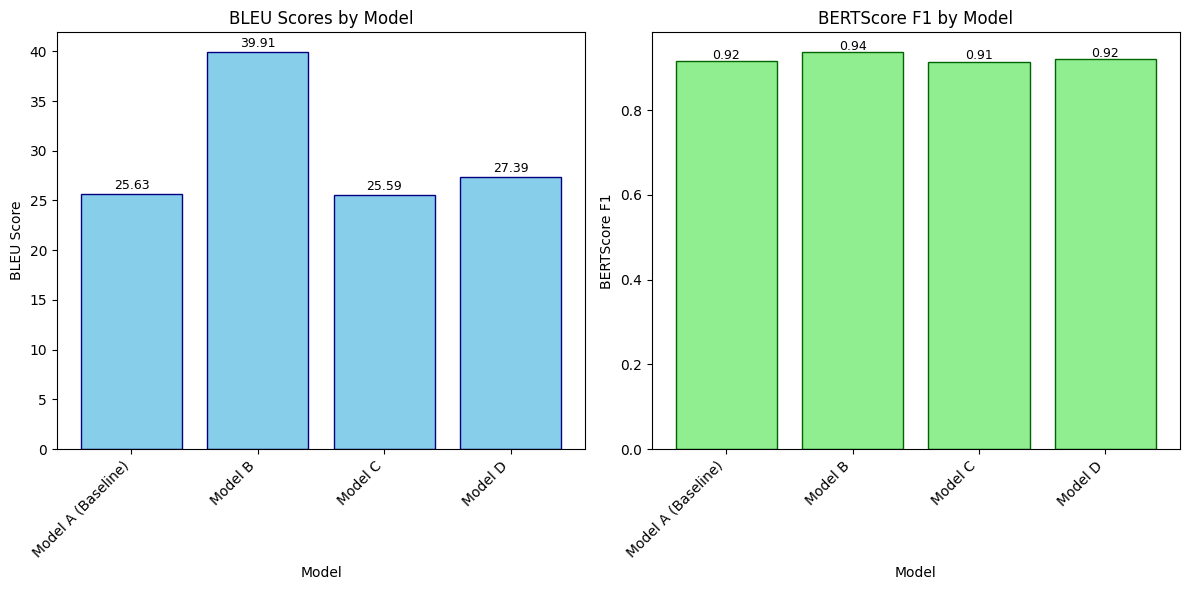

In [ ]:
# Read the JSON files
def read_json(filename):
    with open(filename, 'r') as f:
        return json.load(f)

# List of result files
result_files = [
    'evaluation_results_a.json',
    'evaluation_results_b.json',
    'evaluation_results_c.json',
    'evaluation_results_d.json'
]

# Parse results
results = [read_json(file) for file in result_files]

# Prepare data for plotting
model_names = [result['model_name'] for result in results]
bleu_scores = [result['bleu'] for result in results]
bertscore_f1 = [result['bertscore_f1'] for result in results]

# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# BLEU Score Bar Plot
plt.subplot(1, 2, 1)
plt.bar(model_names, bleu_scores, color='skyblue', edgecolor='navy')
plt.title('BLEU Scores by Model', fontsize=12)
plt.xlabel('Model', fontsize=10)
plt.ylabel('BLEU Score', fontsize=10)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(bleu_scores):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center', fontsize=9)

# BERTScore F1 Bar Plot
plt.subplot(1, 2, 2)
plt.bar(model_names, bertscore_f1, color='lightgreen', edgecolor='darkgreen')
plt.title('BERTScore F1 by Model', fontsize=12)
plt.xlabel('Model', fontsize=10)
plt.ylabel('BERTScore F1', fontsize=10)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(bertscore_f1):
    plt.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=9)

# Adjust layout and save
plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')

# Print out the results for reference
print("Model Performance Comparison:")
for result in results:
    print(f"{result['model_name']}:")
    print(f"  BLEU Score: {result['bleu']:.4f}")
    print(f"  BERTScore F1: {result['bertscore_f1']:.4f}")

In [ ]:
!zip -r ./model-b.zip ./model-b/checkpoint-200

  adding: model-b/checkpoint-200/ (stored 0%)
  adding: model-b/checkpoint-200/rng_state.pth (deflated 25%)
  adding: model-b/checkpoint-200/README.md (deflated 66%)
  adding: model-b/checkpoint-200/tokenizer.json (deflated 79%)
  adding: model-b/checkpoint-200/scheduler.pt (deflated 56%)
  adding: model-b/checkpoint-200/scaler.pt (deflated 60%)
  adding: model-b/checkpoint-200/special_tokens_map.json (deflated 73%)
  adding: model-b/checkpoint-200/tokenizer_config.json (deflated 73%)
  adding: model-b/checkpoint-200/adapter_model.safetensors (deflated 7%)
  adding: model-b/checkpoint-200/adapter_config.json (deflated 53%)
  adding: model-b/checkpoint-200/optimizer.pt (deflated 19%)
  adding: model-b/checkpoint-200/trainer_state.json (deflated 70%)
  adding: model-b/checkpoint-200/training_args.bin (deflated 51%)


In [ ]:
!zip -r ./model-c.zip ./model-c/checkpoint-400

  adding: model-c/checkpoint-400/ (stored 0%)
  adding: model-c/checkpoint-400/rng_state.pth (deflated 25%)
  adding: model-c/checkpoint-400/README.md (deflated 66%)
  adding: model-c/checkpoint-400/tokenizer.json (deflated 79%)
  adding: model-c/checkpoint-400/scheduler.pt (deflated 55%)
  adding: model-c/checkpoint-400/scaler.pt (deflated 60%)
  adding: model-c/checkpoint-400/special_tokens_map.json (deflated 73%)
  adding: model-c/checkpoint-400/tokenizer_config.json (deflated 73%)
  adding: model-c/checkpoint-400/adapter_model.safetensors (deflated 7%)
  adding: model-c/checkpoint-400/adapter_config.json (deflated 53%)
  adding: model-c/checkpoint-400/optimizer.pt (deflated 19%)
  adding: model-c/checkpoint-400/trainer_state.json (deflated 76%)
  adding: model-c/checkpoint-400/training_args.bin (deflated 51%)


In [ ]:
!zip -r ./model-d.zip ./model-d/checkpoint-600

  adding: model-d/checkpoint-600/ (stored 0%)
  adding: model-d/checkpoint-600/rng_state.pth (deflated 25%)
  adding: model-d/checkpoint-600/README.md (deflated 66%)
  adding: model-d/checkpoint-600/tokenizer.json (deflated 79%)
  adding: model-d/checkpoint-600/scheduler.pt (deflated 55%)
  adding: model-d/checkpoint-600/scaler.pt (deflated 60%)
  adding: model-d/checkpoint-600/special_tokens_map.json (deflated 73%)
  adding: model-d/checkpoint-600/tokenizer_config.json (deflated 73%)
  adding: model-d/checkpoint-600/adapter_model.safetensors (deflated 7%)
  adding: model-d/checkpoint-600/adapter_config.json (deflated 53%)
  adding: model-d/checkpoint-600/optimizer.pt (deflated 18%)
  adding: model-d/checkpoint-600/trainer_state.json (deflated 79%)
  adding: model-d/checkpoint-600/training_args.bin (deflated 51%)


In [ ]:
files.download("./model-b.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>